In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression


In [2]:
df = pd.read_csv(r"C:\Users\shrey\OneDrive\Desktop\retail-demand-forecasting\data\processed\train_features.csv")

# Fix datetime
df['Date'] = pd.to_datetime(df['Date'])

In [3]:
# Define features and target variable 
X = df.drop(['Weekly_Sales', 'Date'], axis=1)  # Date is excluded as the date is already extracted into features like month, week, etc.
y = df['Weekly_Sales']

In [4]:
# DEfine feature type 
categorical_features = ['Type']
numerical_features = [col for col in X.columns if col not in categorical_features]

In [5]:
# DEfine the preprocessor 
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)

In [6]:
# BUild the pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [34]:
# Train and Test split 
# Sort by Date first
df = df.sort_values('Date')

# 80/20 split index
split_index = int(len(df) * 0.8)

# Split dataframe
train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

# Create X and y
X_train = train_df.drop(['Weekly_Sales', 'Date'], axis=1)
y_train = train_df['Weekly_Sales']

X_test = test_df.drop(['Weekly_Sales', 'Date'], axis=1)
y_test = test_df['Weekly_Sales']

print(X_train.shape, X_test.shape)

(326748, 23) (81688, 23)


In [35]:

print(X_train.columns)

Index(['Store', 'Dept', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2',
       'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Type',
       'Size', 'IsHoliday', 'Year', 'Month', 'Week', 'DayOfWeek', 'Lag_1',
       'Lag_2', 'Lag_4', 'Rolling_Mean_4', 'Rolling_Std_4'],
      dtype='str')


# MODEL TRAINING AND COMPARISON 


In [36]:
# define the mdel with same preprocessor and regressor 

#linear regression (baseline)
from sklearn.linear_model import LinearRegression

model_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])



In [37]:
#decision tree 
from sklearn.tree import DecisionTreeRegressor

model_dt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

In [38]:
# Random forest 
from sklearn.ensemble import RandomForestRegressor


# Model tuning 
model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=50,
        max_depth=15,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    ))
])

In [39]:
# Evaluation metrics 

from sklearn.metrics import mean_squared_error
import numpy as np

def evaluate(model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    
    return mse, rmse


In [40]:


results = {}

results['Linear Regression'] = evaluate(model_lr)
results['Decision Tree'] = evaluate(model_dt)
results['Random Forest'] = evaluate(model_rf)

print(results)

{'Linear Regression': (10314224.675963767, 3211.576665123186), 'Decision Tree': (35736599.77000945, 5978.009682997297), 'Random Forest': (8854467.923728157, 2975.6457994405446)}


In [41]:
results['Random Forest Tuned'] = evaluate(model_rf)
print(results)

{'Linear Regression': (10314224.675963767, 3211.576665123186), 'Decision Tree': (35736599.77000945, 5978.009682997297), 'Random Forest': (8854467.923728157, 2975.6457994405446), 'Random Forest Tuned': (8854467.923728157, 2975.6457994405446)}


In [42]:
from sklearn.ensemble import HistGradientBoostingRegressor

model_hgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', HistGradientBoostingRegressor(max_iter=100))
])


results['HistGB'] = evaluate(model_hgb)
print(results)

{'Linear Regression': (10314224.675963767, 3211.576665123186), 'Decision Tree': (35736599.77000945, 5978.009682997297), 'Random Forest': (8854467.923728157, 2975.6457994405446), 'Random Forest Tuned': (8854467.923728157, 2975.6457994405446), 'HistGB': (8959539.512353504, 2993.2489893681586)}


In [45]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predict on validation set
y_pred = model_hgb.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("HistGradientBoosting Performance")
print("R2 Score :", round(r2, 4))
print("MAE      :", round(mae, 2))
print("MSE      :", round(mse, 2))
print("RMSE     :", round(rmse, 2))

HistGradientBoosting Performance
R2 Score : 0.9815
MAE      : 1443.72
MSE      : 8959539.51
RMSE     : 2993.25


In [46]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

pred = model_rf.predict(X_test)

print("R2 :", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

R2 : 0.98167486097478
MAE: 1394.8807657975617
RMSE: 2975.645799440544


In [44]:
from xgboost import XGBRegressor

model_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])

results['XGBoost'] = evaluate(model_xgb)
print(results)

{'Linear Regression': (10314224.675963767, 3211.576665123186), 'Decision Tree': (35736599.77000945, 5978.009682997297), 'Random Forest': (8854467.923728157, 2975.6457994405446), 'Random Forest Tuned': (8854467.923728157, 2975.6457994405446), 'HistGB': (8959539.512353504, 2993.2489893681586), 'XGBoost': (9238615.51616219, 3039.509091310995)}


# ==============================
# TEST DATA PIPELINE
# ==============================

In [47]:
# load the test data 

import pandas as pd 

test = pd.read_csv(r"C:\Users\shrey\OneDrive\Desktop\retail-demand-forecasting\data\raw\test.csv")
stores= pd.read_csv(r"C:\Users\shrey\OneDrive\Desktop\retail-demand-forecasting\data\raw\stores.csv")
features = pd.read_csv(r"C:\Users\shrey\OneDrive\Desktop\retail-demand-forecasting\data\raw\features.csv")


In [48]:
# merge the data sames as train

test = pd.merge(test, features, on=['Store', 'Date'], how='left')
test = pd.merge(test, stores, on='Store', how='left')
print(test.columns)

Index(['Store', 'Dept', 'Date', 'IsHoliday_x', 'Temperature', 'Fuel_Price',
       'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI',
       'Unemployment', 'IsHoliday_y', 'Type', 'Size'],
      dtype='str')


In [49]:
# Fix the isholiday 
test['IsHoliday'] = test['IsHoliday_x']
test.drop(['IsHoliday_x', 'IsHoliday_y'], axis=1, inplace=True)


In [50]:
print(test.columns)

Index(['Store', 'Dept', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1',
       'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI',
       'Unemployment', 'Type', 'Size', 'IsHoliday'],
      dtype='str')


In [51]:
# fill markdown 
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
test[markdown_cols] = test[markdown_cols].fillna(0)

In [52]:
# DAte feature 
test['Date'] = pd.to_datetime(test['Date'])

test['Year'] = test['Date'].dt.year
test['Month'] = test['Date'].dt.month
test['Week'] = test['Date'].dt.isocalendar().week
test['DayOfWeek'] = test['Date'].dt.dayofweek

In [53]:
# The lag and rolling features set to 0 as there is no weekly sales data # Check this later 
test['Lag_1'] = 0
test['Lag_2'] = 0
test['Lag_4'] = 0

test['Rolling_Mean_4'] = 0
test['Rolling_Std_4'] = 0

In [54]:
# Final model prediction - model used is random forest 
X_test_final = test.drop(['Date'], axis=1)
# Ensure test columns match training columns exactly
X_test_final = X_test_final[X.columns]

model_rf.fit(X, y)

predictions = model_rf.predict(X_test_final)

In [58]:
# Fit final model first
model_rf.fit(X_train, y_train)

# Predict on validation set
y_pred = model_rf.predict(X_test)

# Comparison dataframe
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison["Error"] = comparison["Actual"] - comparison["Predicted"]
comparison["Abs_Error"] = comparison["Error"].abs()

print(comparison.head(20))

      Actual     Predicted         Error     Abs_Error
0     526.42    541.570549    -15.150549     15.150549
1   86675.04  51317.421862  35357.618138  35357.618138
2   16534.02  16200.194539    333.825461    333.825461
3   15447.44  16340.291214   -892.851214    892.851214
4    1127.87   1606.162458   -478.292458    478.292458
5    6943.22   6738.313463    204.906537    204.906537
6    3259.16   3605.581580   -346.421580    346.421580
7    3540.56   3825.394469   -284.834469    284.834469
8    8549.05   8790.770345   -241.720345    241.720345
9    6944.57   8437.170475  -1492.600475   1492.600475
10   1992.68   2445.434843   -452.754843    452.754843
11  12748.09  13767.397509  -1019.307509   1019.307509
12   7489.78  10430.874588  -2941.094588   2941.094588
13    863.00   1217.917048   -354.917048    354.917048
14   4227.26   4789.292905   -562.032905    562.032905
15  24681.42  24518.225154    163.194846    163.194846
16  13646.80  13389.383649    257.416351    257.416351
17   3413.

Average Absolute Error: 1394.8807657975617
Median Absolute Error: 556.1428939206667


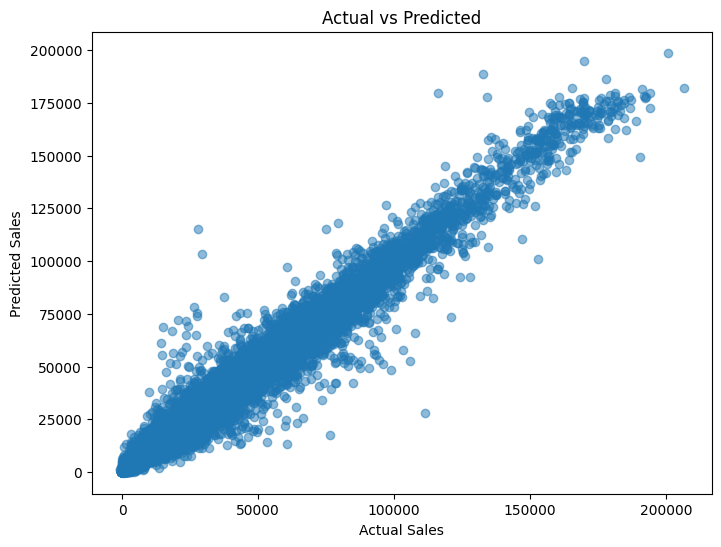

In [59]:
print("Average Absolute Error:", comparison['Abs_Error'].mean())
print("Median Absolute Error:", comparison['Abs_Error'].median())

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(comparison['Actual'], comparison['Predicted'], alpha=0.5)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")
plt.show()

In [56]:
# Should still run this once check the smaplesubmiision.csv and then add in the raw folder 
import pandas as pd 
sample = pd.read_csv(r"C:\Users\shrey\OneDrive\Desktop\retail-demand-forecasting\data\raw\sampleSubmission.csv")

sample['Weekly_Sales'] = predictions

sample.to_csv(r"C:\Users\shrey\OneDrive\Desktop\retail-demand-forecasting\data\processed\final_submission.csv", index=False)

In [57]:
# Saving the final model 

import joblib
model.fit(X_train, y_train)
joblib.dump(model_rf, r"C:\Users\shrey\OneDrive\Desktop\retail-demand-forecasting\models\model.pkl")

['C:\\Users\\shrey\\OneDrive\\Desktop\\retail-demand-forecasting\\models\\model.pkl']